<a href="https://colab.research.google.com/github/RafaelaMlucca/skin-lesion-classification-ham10000/blob/main/02_experiments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projeto IA — HAM10000: Experimentos

Comparação de duas abordagens para classificar as 7 classes de lesões de pele:

- **Modelo A — extrai-e-classifica:** backbone **DINOv2 (ViT-S/14) congelado** como extrator de features → **SVM**.
- **Modelo B — fine-tuning end-to-end:** **EfficientNetV2-S** pré-treinado, ajustado para as 7 classes.

Pontos de rigor já embutidos: split **agrupado por `lesion_id`** (anti-vazamento), **class weights** para o desbalanceamento, e avaliação por **macro-F1 / balanced accuracy / matriz de confusão / recall de melanoma**.


## 0. Setup

In [1]:
!pip install -q timm kagglehub

In [2]:
import os, time, copy, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import timm

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,
                             classification_report, confusion_matrix)

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', device)
RESULTS_DIR = 'results'; os.makedirs(RESULTS_DIR, exist_ok=True)

Device: cuda


## 1. Dados, rótulos e caminhos das imagens

In [3]:
import kagglehub
DATA_DIR = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
print("DATA_DIR:", DATA_DIR)

df = pd.read_csv(os.path.join(DATA_DIR, 'HAM10000_metadata.csv'))

# image_id -> caminho do arquivo
img_paths = {}
for root, _, files in os.walk(DATA_DIR):
    for f in files:
        if f.lower().endswith('.jpg'):
            img_paths[os.path.splitext(f)[0]] = os.path.join(root, f)

df['path'] = df['image_id'].map(img_paths)
df = df.dropna(subset=['path']).reset_index(drop=True)

CLASSES = sorted(df['dx'].unique().tolist())          # ['akiec','bcc','bkl','df','mel','nv','vasc']
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}
df['label'] = df['dx'].map(CLASS_TO_IDX)
MEL_IDX = CLASS_TO_IDX['mel']

print('Imagens utilizáveis:', len(df))
print('Classes:', CLASSES)
print(df['dx'].value_counts())

Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
DATA_DIR: /kaggle/input/skin-cancer-mnist-ham10000
Imagens utilizáveis: 10015
Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


## 2. Split agrupado por `lesion_id` (estratificado)

Duas passagens de `StratifiedGroupKFold`: primeiro separa o **teste** (~20%), depois a **validação** (~20% do restante). Nenhuma lesão aparece em mais de um conjunto.

In [4]:
def grouped_split(frame, seed=SEED):
    idx = np.arange(len(frame)); y = frame['label'].values; g = frame['lesion_id'].values
    sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=seed)
    trainval_pos, test_pos = next(sgkf.split(idx, y, g))
    tv = frame.iloc[trainval_pos].reset_index(drop=True)
    sgkf2 = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=seed)
    tr_pos, val_pos = next(sgkf2.split(np.arange(len(tv)), tv['label'].values, tv['lesion_id'].values))
    return (tv.iloc[tr_pos].reset_index(drop=True),
            tv.iloc[val_pos].reset_index(drop=True),
            frame.iloc[test_pos].reset_index(drop=True))

train_df, val_df, test_df = grouped_split(df)

# Garantia: nenhuma lesão vaza entre os conjuntos
s_tr, s_val, s_te = set(train_df['lesion_id']), set(val_df['lesion_id']), set(test_df['lesion_id'])
assert not (s_tr & s_val) and not (s_tr & s_te) and not (s_val & s_te), 'VAZAMENTO de lesion_id!'

print(f'Treino: {len(train_df)} | Val: {len(val_df)} | Teste: {len(test_df)}')
print('\nDistribuição (%) por conjunto:')
for nm, d in [('treino', train_df), ('val', val_df), ('teste', test_df)]:
    print(nm, (d['dx'].value_counts(normalize=True)*100).round(1).to_dict())

Treino: 6409 | Val: 1592 | Teste: 2014

Distribuição (%) por conjunto:
treino {'nv': 66.3, 'bkl': 11.4, 'mel': 11.4, 'bcc': 5.4, 'akiec': 3.2, 'df': 1.2, 'vasc': 1.1}
val {'nv': 68.7, 'bkl': 10.3, 'mel': 10.2, 'bcc': 4.5, 'akiec': 3.2, 'vasc': 2.2, 'df': 0.9}
teste {'nv': 67.7, 'mel': 11.0, 'bkl': 10.2, 'bcc': 5.0, 'akiec': 3.4, 'vasc': 1.7, 'df': 1.1}


## 3. Transforms e Dataset

In [5]:
IMG_SIZE = 224
MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]   # ImageNet

eval_tf = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(MEAN, STD),
])

train_tf = T.Compose([
    T.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    T.RandomHorizontalFlip(), T.RandomVerticalFlip(),
    T.RandomRotation(20),
    T.ColorJitter(0.1, 0.1, 0.1),
    T.ToTensor(),
    T.Normalize(MEAN, STD),
])

class HAMDataset(Dataset):
    def __init__(self, frame, transform):
        self.frame = frame.reset_index(drop=True); self.transform = transform
    def __len__(self): return len(self.frame)
    def __getitem__(self, i):
        row = self.frame.iloc[i]
        img = Image.open(row['path']).convert('RGB')
        return self.transform(img), int(row['label'])

## 4. Funções de avaliação

In [6]:
def evaluate(y_true, y_pred, name):
    acc  = accuracy_score(y_true, y_pred)
    bacc = balanced_accuracy_score(y_true, y_pred)
    mf1  = f1_score(y_true, y_pred, average='macro')
    cm   = confusion_matrix(y_true, y_pred, labels=range(len(CLASSES)))
    rec_mel = cm[MEL_IDX, MEL_IDX] / cm[MEL_IDX].sum() if cm[MEL_IDX].sum() else 0.0

    print(f'\n===== {name} =====')
    print(f'Acurácia: {acc:.3f} | Balanced acc: {bacc:.3f} | Macro-F1: {mf1:.3f} | Recall melanoma: {rec_mel:.3f}')
    print(classification_report(y_true, y_pred, target_names=CLASSES, digits=3, zero_division=0))

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, cmap='Blues'); fig.colorbar(im)
    ax.set_xticks(range(len(CLASSES))); ax.set_xticklabels(CLASSES, rotation=45, ha='right')
    ax.set_yticks(range(len(CLASSES))); ax.set_yticklabels(CLASSES)
    ax.set_xlabel('Predito'); ax.set_ylabel('Verdadeiro'); ax.set_title(f'Matriz de confusão — {name}')
    for i in range(len(CLASSES)):
        for j in range(len(CLASSES)):
            ax.text(j, i, cm[i, j], ha='center', va='center',
                    color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=8)
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, f'cm_{name}.png'), dpi=120); plt.show()

    return {'modelo': name, 'acuracia': acc, 'balanced_acc': bacc,
            'macro_f1': mf1, 'recall_melanoma': rec_mel}

## 5. Modelo A — DINOv2 (congelado) + SVM

O backbone só faz inferência (sem gradiente). Extraímos um vetor de features por imagem e treinamos um SVM com `class_weight='balanced'`.

In [7]:
# Backbone DINOv2 ViT-S/14 como extrator (num_classes=0 -> retorna o embedding)
backbone = timm.create_model('vit_small_patch14_dinov2.lvd142m',
                             pretrained=True, num_classes=0, img_size=IMG_SIZE)
backbone = backbone.eval().to(device)
for p in backbone.parameters():
    p.requires_grad_(False)
print('Dim do embedding:', backbone.num_features)

@torch.no_grad()
def extract_features(frame):
    loader = DataLoader(HAMDataset(frame, eval_tf), batch_size=64, shuffle=False, num_workers=2)
    feats, labels = [], []
    for x, y in loader:
        f = backbone(x.to(device))
        feats.append(f.cpu().numpy()); labels.append(y.numpy())
    return np.concatenate(feats), np.concatenate(labels)

print('Extraindo features (pode levar alguns minutos)...')
Xtr, ytr = extract_features(train_df)
Xval, yval = extract_features(val_df)
Xte, yte = extract_features(test_df)
print('Shapes:', Xtr.shape, Xval.shape, Xte.shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

Dim do embedding: 384
Extraindo features (pode levar alguns minutos)...
Shapes: (6409, 384) (1592, 384) (2014, 384)


Macro-F1 (val): 0.59

===== A_DINOv2_SVM =====
Acurácia: 0.791 | Balanced acc: 0.534 | Macro-F1: 0.568 | Recall melanoma: 0.509
              precision    recall  f1-score   support

       akiec      0.514     0.529     0.522        68
         bcc      0.565     0.610     0.587       100
         bkl      0.532     0.566     0.548       205
          df      0.625     0.227     0.333        22
         mel      0.574     0.509     0.539       222
          nv      0.893     0.917     0.905      1363
        vasc      0.929     0.382     0.542        34

    accuracy                          0.791      2014
   macro avg      0.662     0.534     0.568      2014
weighted avg      0.790     0.791     0.787      2014



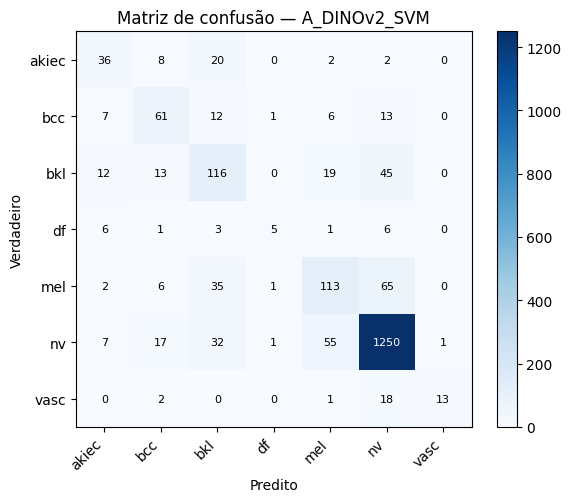

In [8]:
scaler = StandardScaler().fit(Xtr)
svm = SVC(kernel='rbf', C=10, gamma='scale', class_weight='balanced', random_state=SEED)
svm.fit(scaler.transform(Xtr), ytr)

pred_val_A = svm.predict(scaler.transform(Xval))
pred_te_A  = svm.predict(scaler.transform(Xte))
print('Macro-F1 (val):', round(f1_score(yval, pred_val_A, average='macro'), 3))
res_A = evaluate(yte, pred_te_A, 'A_DINOv2_SVM')

## 6. Modelo B — EfficientNetV2-S (fine-tuning)

Treino end-to-end com `CrossEntropyLoss` ponderada pelas classes, augmentation no treino, AdamW e mixed precision. Guardamos o melhor estado pela **macro-F1 de validação**.

In [ ]:
BATCH = 32; EPOCHS = 6; LR = 1e-4

train_loader = DataLoader(HAMDataset(train_df, train_tf), batch_size=BATCH, shuffle=True, num_workers=2)
val_loader   = DataLoader(HAMDataset(val_df, eval_tf),   batch_size=BATCH, shuffle=False, num_workers=2)
test_loader  = DataLoader(HAMDataset(test_df, eval_tf),  batch_size=BATCH, shuffle=False, num_workers=2)

# Pesos de classe (inverso da frequência) para a loss
counts = train_df['label'].value_counts().sort_index().values
class_w = torch.tensor((counts.sum() / (len(counts) * counts)), dtype=torch.float32).to(device)

model_b = timm.create_model('tf_efficientnetv2_s.in21k_ft_in1k',
                            pretrained=True, num_classes=len(CLASSES)).to(device)
criterion = nn.CrossEntropyLoss(weight=class_w)
optimizer = torch.optim.AdamW(model_b.parameters(), lr=LR, weight_decay=1e-4)
scaler_amp = torch.cuda.amp.GradScaler(enabled=(device == 'cuda'))

@torch.no_grad()
def predict_loader(model, loader):
    model.eval(); ys, ps = [], []
    for x, y in loader:
        with torch.cuda.amp.autocast(enabled=(device == 'cuda')):
            out = model(x.to(device))
        ps.append(out.argmax(1).cpu().numpy()); ys.append(y.numpy())
    return np.concatenate(ys), np.concatenate(ps)

best_f1, best_state = -1.0, None
for epoch in range(EPOCHS):
    model_b.train(); t0 = time.time(); running = 0.0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        with torch.cuda.amp.autocast(enabled=(device == 'cuda')):
            loss = criterion(model_b(x), y)
        scaler_amp.scale(loss).backward(); scaler_amp.step(optimizer); scaler_amp.update()
        running += loss.item() * x.size(0)
    yv, pv = predict_loader(model_b, val_loader)
    vf1 = f1_score(yv, pv, average='macro')
    print(f'Época {epoch+1}/{EPOCHS} | loss {running/len(train_df):.3f} | val macro-F1 {vf1:.3f} | {time.time()-t0:.0f}s')
    if vf1 > best_f1:
        best_f1, best_state = vf1, copy.deepcopy(model_b.state_dict())

model_b.load_state_dict(best_state)
print('Melhor val macro-F1:', round(best_f1, 3))

model.safetensors:   0%|          | 0.00/86.5M [00:00<?, ?B/s]

/tmp/ipykernel_1359/2753925669.py:15: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_amp = torch.cuda.amp.GradScaler(enabled=(device == 'cuda'))
/tmp/ipykernel_1359/2753925669.py:32: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device == 'cuda')):


In [ ]:
yte_b, pred_te_B = predict_loader(model_b, test_loader)
res_B = evaluate(yte_b, pred_te_B, 'B_EfficientNetV2_finetune')

## 7. Comparação final

In [ ]:
comp = pd.DataFrame([res_A, res_B]).set_index('modelo').round(3)
comp.to_csv(os.path.join(RESULTS_DIR, 'comparacao_modelos.csv'))
print(comp)

comp[['acuracia', 'balanced_acc', 'macro_f1', 'recall_melanoma']].plot(
    kind='bar', figsize=(9, 5))
plt.title('A (DINOv2+SVM) vs B (EfficientNetV2 fine-tuning)')
plt.ylabel('métrica'); plt.xticks(rotation=0); plt.ylim(0, 1)
plt.legend(loc='lower right'); plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'comparacao_modelos.png'), dpi=120); plt.show()